This notebook plots the solutions. You can actually plot the progress while the solver is running to see if it makes sense.

Various imports:

In [1]:
%load_ext autoreload
%autoreload 2
# add path to code
import sys
sys.path.insert(0, '../source')
import numpy as np
from matplotlib.tri import Triangulation
from matplotlib import colors
import matplotlib.pyplot as plt
import matplotlib as mpl
import topotoolbox as tt3
from params import rho_w,g
from scipy.stats import linregress
from load_lakes import lake_inventory
import json
from shapely import Point

In [2]:
#choose which results to load
results_name = '../results/example'

In [3]:
t = np.load(results_name+'/t.npy')
nodes_x = np.load(results_name+'/nodes_x.npy')/1e3
nodes_y = np.load(results_name+'/nodes_y.npy')/1e3
dofmap = np.load(results_name+'/dofmap.npy')
lake_bdry = np.load(results_name+'/lake_bdry.npy')
triang = Triangulation(nodes_x,nodes_y,dofmap)

# load results and reorder dof's to the serial ordering
N = np.load(results_name+'/N.npy')
b = np.load(results_name+'/b.npy')
qx = np.load(results_name+'/qx.npy')
qy = np.load(results_name+'/qy.npy')
outflow_dofs = np.load(results_name+'/outflow_dofs.npy')

boundary_coords = np.load(results_name+'/boundary_coords.npy')/1e3
outflow_coords = np.load(results_name+'/outflow_coords.npy')/1e3
inflow_coords = np.load(results_name+'/inflow_coords.npy')/1e3


# get water flow speed
q_m = np.sqrt(qx**2+qy**2)

with open(results_name+"/model_config.json", "r") as f:
    model_config = json.load(f)

neighbors = []#model_config['neighbors']
lake_name = model_config['lake_name']
outflow_on = model_config['outflow_on']
storage_on = model_config['storage_on']
N_bdry = model_config['N_bdry']
x_min = model_config['x_min']/1e3
x_max = model_config['x_max']/1e3
y_min = model_config['y_min']/1e3
y_max = model_config['y_max']/1e3


In [4]:
N_bdry/1e6

2.2489425

In [5]:
# get mean of N over the lake and max of q not over the lake
N_mean = np.zeros(t.size)
b_mean = np.zeros(t.size)
q_max = np.zeros(t.size)

j_max=0


for j in range(t.size):
    if np.max(q_m[j,:]>1e-10):
        N_j = N[j,:]
        q_j = q_m[j,:]
        
        if np.max(lake_bdry)>1e-10:
            # if storage take mean of pressure over lake area
            # and max of disharge 
            N_mean[j] = np.mean(N_j[lake_bdry>1e-1])
            q_max[j] = np.max(q_j[lake_bdry>1e-1])
            

        else:
            # if no lake, just take mean over whole domain
            N_mean[j] = np.mean(N_j)
            q_max[j] = np.mean(q_j)
            
        j_max+=1 
j_max -= 1

# storage in the lake, assuming water density 1000 kg/m^3
b_L = -(N_mean-N_mean[0])/(rho_w*g)

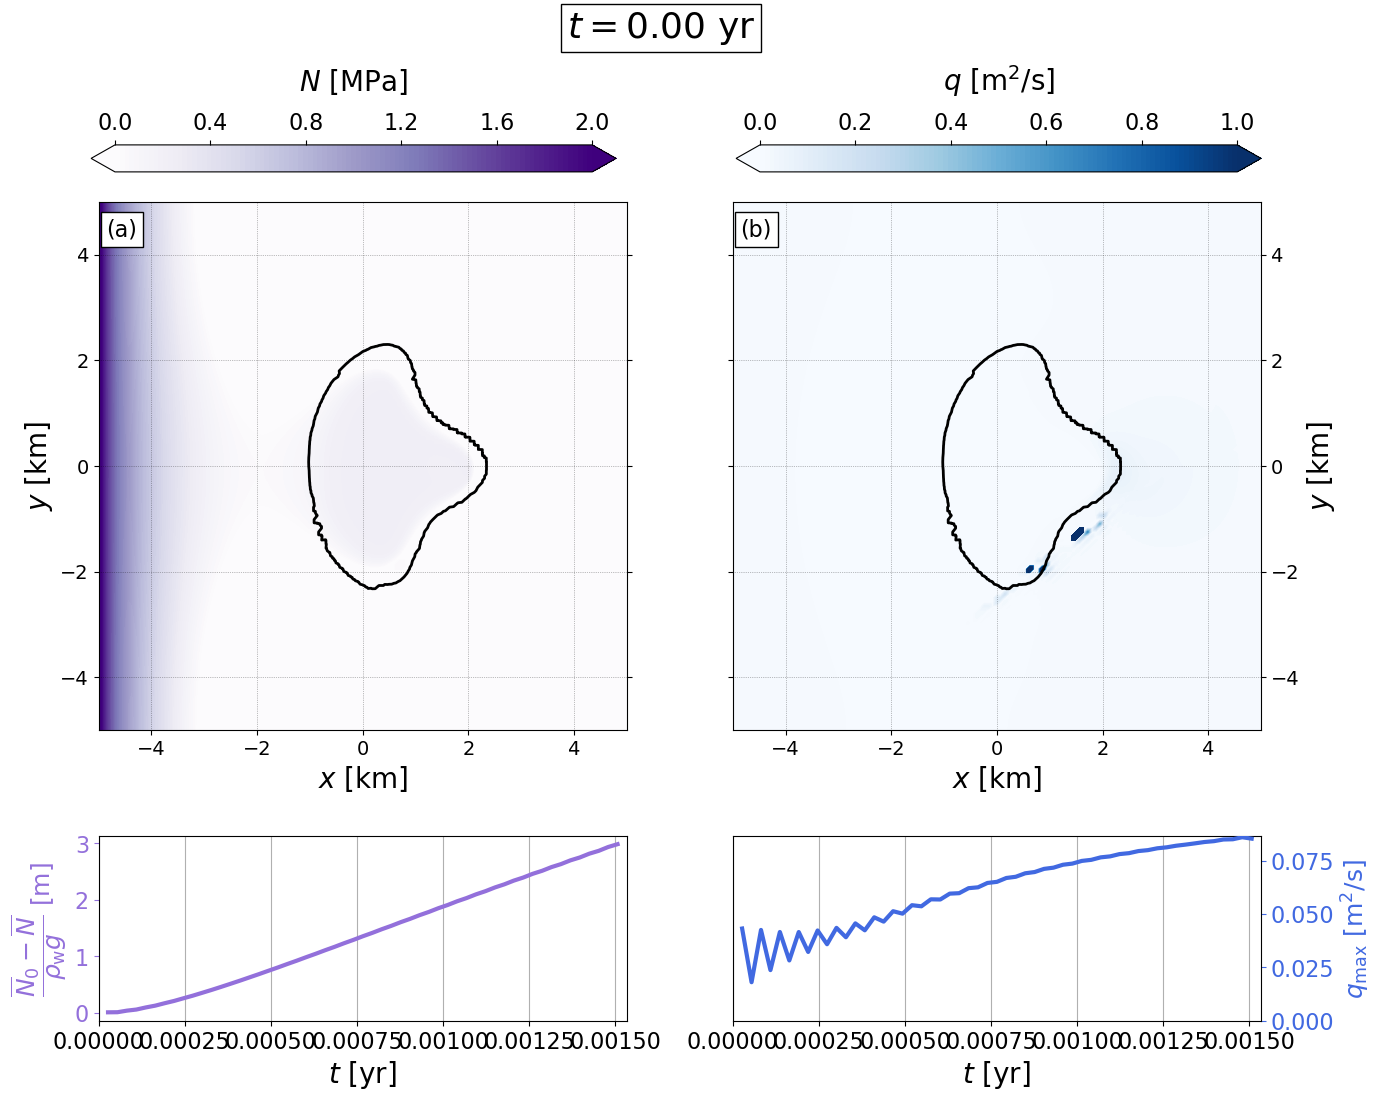

In [6]:
# choose to plot a single timestep OR a sequence to make a movie
ind = [j_max]               # plot a single time step
# ind = np.arange(1,j_max,1) # plot every time step for saving a movie

# make clean movie directory
# !rm -rf {results_name}/movie
# !mkdir {results_name}/movie

j=0

if len(ind)>1:
# use agg backend for saving pngs
    mpl.use('agg')
else:
    %matplotlib inline

qlim2 = 0 
qlim1 = -3 

t_scale = 1.0 # 1 for years, 365 for days
if int(t_scale)==365:
    t_str = 'd' 
elif int(t_scale)==1:
    t_str = 'yr'
slope, intercept, r_value, p_value, std_err = linregress(t[int(0.5*(j_max)):j_max]*(t_scale/3.154e7), b_L[int(0.5*(j_max)):j_max])

slope2, intercept2, r_value2, p_value2, std_err2 = linregress(t[int(0.5*(j_max)):j_max]*(t_scale/3.154e7), b_mean[int(0.5*(j_max)):j_max])
res_lim = 1

for i in ind:
    print('saved image '+str(j+1)+' out of '+str(len(ind))+' \r',end='')
    
    fig = plt.figure(figsize=(15,12))
    
    plt.suptitle(r'$t=$'+'{:.2f}'.format(t_scale*t[i]/3.154e7)+f' {t_str}',y=0.875,fontsize=26,bbox=dict(facecolor='w', alpha=1))

    ax1 = plt.subplot(121)
    plt.annotate(r'(a)',xy=(0.015,0.935),xycoords='axes fraction',fontsize=16,bbox=dict(facecolor='w', edgecolor='k'))
    plt.grid(alpha=0.5,linestyle=':',color='k',linewidth=0.5)
    N_i = N[i]

    p1 = plt.tricontourf(triang,N_i/1e6,levels=np.linspace(0,2,100),cmap='Purples',extend='both')
    plt.tricontour(triang,lake_bdry,levels=[0.001],colors='k',linestyles='-',linewidths=2)
    # plt.xlim(x_min,x_max)
    # plt.ylim(y_min,y_max)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel(r'$x$ [km]',fontsize=20)
    plt.ylabel(r'$y$ [km]',fontsize=20)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.gca().tick_params(axis='y', which='both', labelright=False, right=True)
    cbar_ax = fig.add_axes([0.12, 0.74, 0.35, 0.0225])
    cbar = plt.colorbar(p1,orientation='horizontal',ticks=np.linspace(0,2,6),cax=cbar_ax)
    cbar.set_label(r'$N$ [MPa]',fontsize=20,labelpad=15)
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')


    ax3 = plt.subplot(122)
    plt.annotate(r'(b)',xy=(0.015,0.935),xycoords='axes fraction',fontsize=16,bbox=dict(facecolor='w', edgecolor='k'))
    plt.grid(alpha=0.5,linestyle=':',color='k',linewidth=0.5)
    q_i = q_m[i]

    p2 = plt.tricontourf(triang,q_i,cmap='Blues',extend='both',levels=np.linspace(0,1,100))  
    plt.tricontour(triang,lake_bdry,levels=[0.001],colors='k',linestyles='-',linewidths=2)
    # plt.xlim(x_min,x_max)
    # plt.ylim(y_min,y_max)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel(r'$x$ [km]',fontsize=20)
    plt.gca().yaxis.set_label_position("right")
    plt.gca().yaxis.tick_right()
    plt.ylabel(r'$y$ [km]',fontsize=20)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.gca().tick_params(axis='y', which='both', labelleft=False, left=True)
    
    cbar_ax = fig.add_axes([0.55, 0.74, 0.35, 0.0225])
    cbar = plt.colorbar(p2,cax=cbar_ax,orientation='horizontal',ticks=np.linspace(0,1,6))#,format='%.0e')
    cbar.set_label(r'$q$ [m$^2/$s]',fontsize=20,labelpad=15)
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')
        
    ax_in1 = ax1.inset_axes([0.0, -0.55, 1, 0.35])
    # line0, = ax_in1.plot(t[1:i]*t_scale/3.154e7,(N_mean[1:i])/1e6,color='mediumpurple',linestyle='-',linewidth=3,zorder=100)
    line0, = ax_in1.plot(t[1:i]*t_scale/3.154e7,b_L[1:i],color='mediumpurple',linestyle='-',linewidth=3,zorder=100)
    ax_in1.tick_params(axis='y', colors="mediumpurple")
    # ax_in1.set_ylabel(r'$\overline{N}$ [MPa]',fontsize=18,color='mediumpurple')
    ax_in1.set_ylabel(r'$\dfrac{\overline{N}_0-\overline{N}}{\rho_\mathrm{w}g}$ [m] ',fontsize=18,color='mediumpurple',zorder=99)
    ax_in1.set_xlim(0,t[j_max]*t_scale/3.154e7)
    ax_in1.grid(axis='x')
    ax_in1.set_xlabel(r'$t$ [yr]',fontsize=20)
    line0.set_clip_on(False)
    ax_in1.tick_params(axis='both', labelsize=16)

    
    ax_in2 = ax3.inset_axes([0.0, -0.55, 1, 0.35])
    ax_in2.plot(t[1:i]*t_scale/3.154e7,q_max[1:i],color='royalblue',linewidth=3,zorder=10) 
    ax_in2.tick_params(axis='y', colors="royalblue")
    ax_in2.yaxis.set_label_position("right")
    ax_in2.yaxis.tick_right()
    ax_in2.set_ylabel(r'${q}_\mathrm{max}$ [m$^2$/s] ',fontsize=18,color='royalblue')
    ax_in2.set_xlim(0,t[j_max]*t_scale/3.154e7)
    ax_in2.set_ylim(0,q_max.max()+0.1*np.std(q_max))
    ax_in2.grid(axis='x')
    ax_in2.set_xlabel(r'$t$ [yr]',fontsize=20)
    ax_in2.tick_params(axis='both', labelsize=16)
    
    
    # axins = ax3.inset_axes([1.1, 1.1, 0.25, 0.25])
    # axins.triplot(triang,color='k',linewidth=1,zorder=100)
    # axins.tricontourf(triang,q_i,cmap='Blues',extend='both',norm=colors.LogNorm(),levels=np.logspace(qlim1,qlim2,100))
    # x_ins = x0 + 50e3
    # y_ins = y0 + 50e3
    # axins.set_xlim(x_ins/1e3-10,x_ins/1e3+10)
    # axins.set_ylim(y_ins/1e3-10,y_ins/1e3+10)
    # axins.set_xticks([])
    # axins.set_yticks([])
    # ax3.indicate_inset_zoom(axins, edgecolor="k",linewidth=1,zorder=300)

    if len(ind)>1:
        plt.savefig('{}/movie/movie_'.format(results_name)+str(j),bbox_inches='tight')
    if len(ind)==1:
        plt.savefig('thw_fig',bbox_inches='tight')
        plt.show()
    plt.close()
    j+=1

In [7]:
b.max()

np.float64(402.63779244753135)